## **Código 6.1**

Primeiras linhas do DataFrame:


,idade,linhas,temp_cli,renda,fatura,temp_rsd,local,tvcabo,debaut,cancel
0,51,3,26,5320,543,7.3,A,sim,nao,nao
1,36,2,16,5620,482,4.5,A,sim,nao,nao
2,35,1,15,4860,593,4.8,A,nao,nao,nao
3,44,1,16,5400,646,6.3,C,sim,sim,sim
4,40,1,22,6590,1184,6.2,C,sim,nao,nao



Sumário do DataFrame:


,idade,linhas,temp_cli,renda,fatura,temp_rsd,local,tvcabo,debaut,cancel
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000,2000,2000,2000
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,A,sim,nao,nao
freq,NaN,NaN,NaN,NaN,NaN,NaN,712,1362,1191,1523
mean,38.42,1.65,20.61,7645.11,748.83,5.01,NaN,NaN,NaN,NaN
std,8.00,0.78,7.17,3795.56,627.13,2.02,NaN,NaN,NaN,NaN
min,23.00,1.00,12.00,4210.00,9.00,0.10,NaN,NaN,NaN,NaN
25%,32.00,1.00,15.00,5420.00,326.75,3.60,NaN,NaN,NaN,NaN
50%,38.00,1.00,19.00,6400.00,582.00,5.00,NaN,NaN,NaN,NaN
75%,44.00,2.00,25.00,8377.50,972.50,6.40,NaN,NaN,NaN,NaN



Tabela cruzada entre 'local' e 'cancel':


cancel,nao,sim
local,,
A,84.7%,15.3%
B,45.6%,54.4%
C,91.7%,8.3%
D,67.7%,32.3%
All,76.1%,23.8%



Modelo podado treinado ainda sem a poda:
DecisionTreeClassifier(min_samples_split=100, random_state=42)


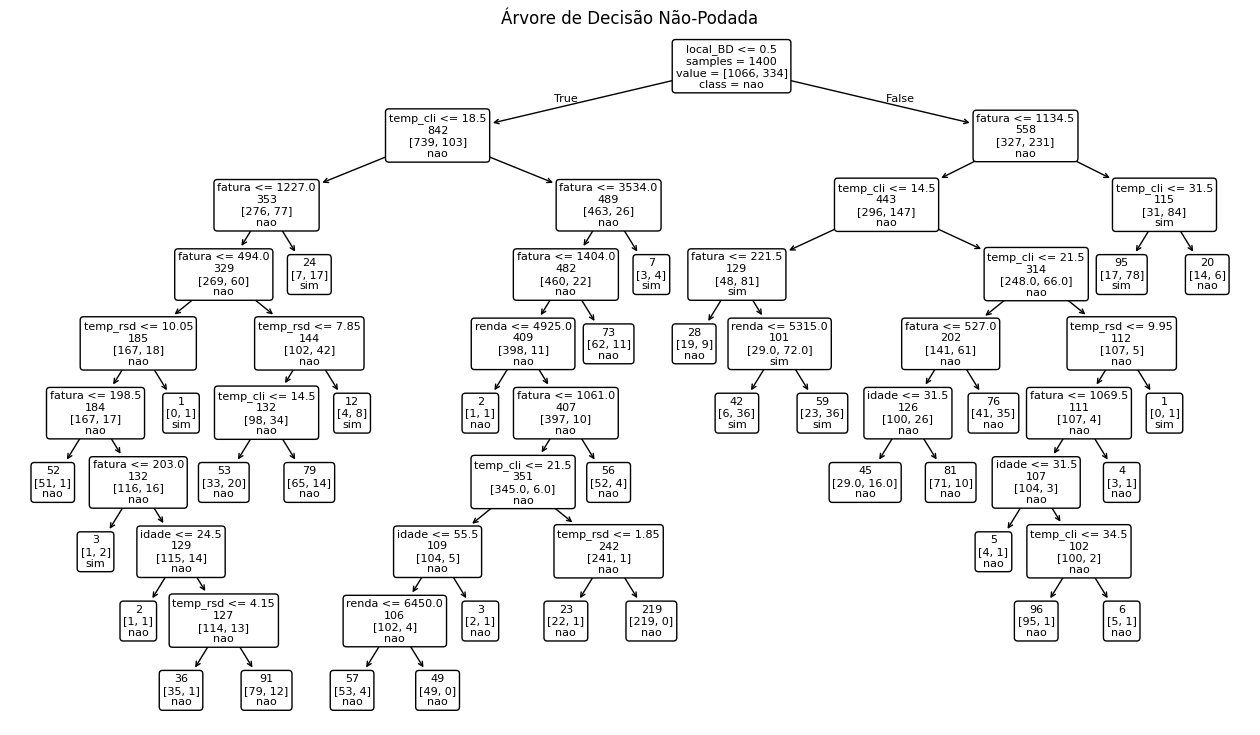

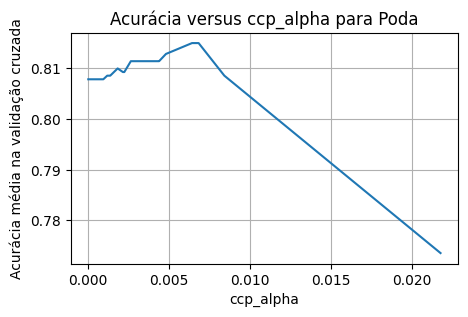


ccp_alpha ótimo encontrado por validação cruzada: 0.00640797646289637

Modelo podado treinado com optimal ccp_alpha:
DecisionTreeClassifier(ccp_alpha=np.float64(0.00640797646289637),
                       min_samples_split=100)


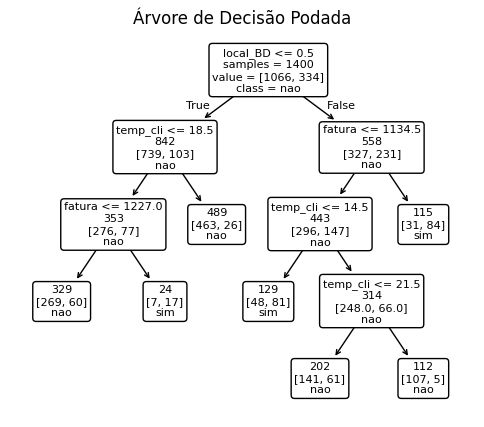


Textual representation of the pruned decision tree:
|--- local_BD <= 0.50
|   |--- temp_cli <= 18.50
|   |   |--- fatura <= 1227.00
|   |   |   |--- class: nao
|   |   |--- fatura >  1227.00
|   |   |   |--- class: sim
|   |--- temp_cli >  18.50
|   |   |--- class: nao
|--- local_BD >  0.50
|   |--- fatura <= 1134.50
|   |   |--- temp_cli <= 14.50
|   |   |   |--- class: sim
|   |   |--- temp_cli >  14.50
|   |   |   |--- temp_cli <= 21.50
|   |   |   |   |--- class: nao
|   |   |   |--- temp_cli >  21.50
|   |   |   |   |--- class: nao
|   |--- fatura >  1134.50
|   |   |--- class: sim



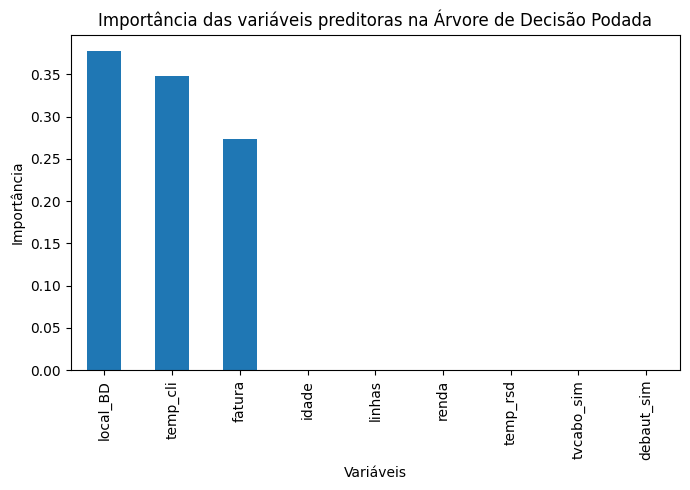


Probabilidades previstas para a amostra de teste (apenas para algumas observações):


,idade,linhas,temp_cli,renda,fatura,temp_rsd,local_BD,tvcabo_sim,debaut_sim,probs
1096,42,3,16,6660,91,5.5,False,True,False,0.182
1668,37,2,23,6770,249,5.3,False,False,False,0.053
957,40,2,29,7160,826,1.1,True,True,True,0.045
129,37,3,12,5990,479,6.7,True,True,False,0.628
15,30,1,23,5750,856,8.1,True,False,False,0.045



Probabilidades previstas para o novo cliente:
   idade  linhas  temp_cli  renda  fatura  temp_rsd  local_BD  tvcabo_sim  \
0     48       2        25   5000    1300         8         1           1   

   debaut_sim  
0           1  
[[0.27 0.73]]

Matriz de Confusão (corte = 0.5):


,Previsto: nao,Previsto: sim
Real: nao,397,60
Real: sim,82,61



Acurácia (corte = 0.5): 0.7633



Matriz de Confusão (corte = 0.2):


,Previsto: nao,Previsto: sim
Real: nao,350,107
Real: sim,52,91



Acurácia (corte = 0.2): 0.7350




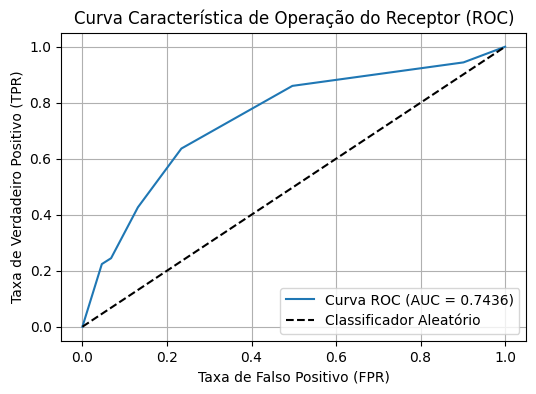

In [1]:
# Importar bibliotecas necessárias.
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Definir a semente de geração de números pseudoaleatórios.
np.random.seed(42)

# Carregar e preparar os dados.
# Apagar a primeira coluna (id dos clientes).
df = pd.read_excel("/content/TECAL.xlsx")
df = df.iloc[:, 1:]

# Exibir um sumário de TECAL (primeiras linhas e infomações estatísticas).
print("Primeiras linhas do DataFrame:")
display(df.head())
print("\nSumário do DataFrame:")
display(df.describe(include='all').round(2))

# Mostrar tabela cruzada entre 'local' e 'cancel'
print("\nTabela cruzada entre 'local' e 'cancel':")
display(pd.crosstab(df['local'], df['cancel'], margins=True, normalize='index').mul(100).map('{:.1f}%'.format))

# Recategorizar a variável 'local' em 'AC' e 'BD'
df['local'] = df['local'].replace('B', 'BD')
df['local'] = df['local'].replace('D', 'BD')
df['local'] = df['local'].replace('A', 'AC')
df['local'] = df['local'].replace('C', 'AC')

# A variável-alvo é cancel (cliente cancela o serviço ou não).
# X_train é o conjunto de variáveis preditoras, na amostra de treino.
# y_train é a variável-alvo, na amostra de treino.
# X_test é o conjunto de variáveis preditoras, na amostra de teste.
# y_train é a variável-alvo, na amostra de teste.
# Dividir a base de dados em amostra de treino (70%) e em amostra de teste (30%).
X = df.drop('cancel', axis=1)
y = df['cancel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Codificação em variáveis dummy para variáveis categóricas.
# Para cada variável categórica, criam-se k-1 variáveis dummy (k é o número de categorias existentes).
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Treinar a árvore de decisão inicial com pre-poda (min_samples_split=100).
model = DecisionTreeClassifier(random_state=42, min_samples_split=100)
model.fit(X_train, y_train)
print("\nModelo podado treinado ainda sem a poda:")
print(model)
plt.figure(figsize=(16, 9))
plot_tree(model, feature_names=X_train.columns, class_names=model.classes_,
          impurity=False, filled=False, rounded=True, fontsize=8,  node_ids=False,
          proportion=False, label='root')
plt.title("Árvore de Decisão Não-Podada")
plt.show()

# Calcular e aplicar a poda (pruning) com validação cruzada.
# Determinar todos ccp_alphas e apagar o relativo à arvore trivial.
# Gerar gráfico ccp_alpha versus Acurácia Média obtida na validação cruzada.
# Imprimir o ccp_alpha ótimo.
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]
cv_results = []
for ccp_alpha in ccp_alphas:
    temp_model = DecisionTreeClassifier(ccp_alpha=ccp_alpha, min_samples_split=100)
    scores = cross_val_score(temp_model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results.append(np.mean(scores))
plt.figure(figsize=(5, 3))
plt.plot(ccp_alphas, cv_results, linestyle='-')
plt.xlabel("ccp_alpha")
plt.ylabel("Acurácia média na validação cruzada")
plt.title("Acurácia versus ccp_alpha para Poda")
plt.grid(True)
plt.show()
optimal_ccp_alpha = ccp_alphas[np.argmax(cv_results)]
print(f"\nccp_alpha ótimo encontrado por validação cruzada: {optimal_ccp_alpha}")

# Treinar o modelo podado com o ccp_alpha ótimo e imprimir a árvore podada.
pruned_model = DecisionTreeClassifier(ccp_alpha=optimal_ccp_alpha, min_samples_split=100)
pruned_model.fit(X_train, y_train)
print("\nModelo podado treinado com optimal ccp_alpha:")
print(pruned_model)
plt.figure(figsize=(6, 5))
plot_tree(pruned_model, feature_names=X_train.columns, class_names=pruned_model.classes_,
          impurity=False, filled=False, rounded=True, fontsize=8,  node_ids=False,
          proportion=False, label='root')
plt.title("Árvore de Decisão Podada")
plt.show()

# Imprimir representação textual da árvore podada.
print("\nTextual representation of the pruned decision tree:")
tree_text = export_text(pruned_model, feature_names=list(X_train.columns))
print(tree_text)

# Mostrar a importância das variáveis preditoras na árvore podada.
feature_importances = pruned_model.feature_importances_
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)
feature_importance_series = feature_importance_series.sort_values(ascending=False)
plt.figure(figsize=(7, 5))
feature_importance_series.plot(kind='bar')
plt.title("Importância das variáveis preditoras na Árvore de Decisão Podada")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.tight_layout()
plt.show()

# Determinar probabilidades (de cancel = sim) previstas para a amostra de teste.
test_probs = pruned_model.predict_proba(X_test)
X_test_with_probs = X_test.copy()
X_test_with_probs['probs'] = test_probs[:, 1]
print("\nProbabilidades previstas para a amostra de teste (apenas para algumas observações):")
display(X_test_with_probs.head().round(3))

# Fazer predições para um "novo cliente".
sim, nao = 1, 0
novo_caso = {
        'idade': [48],
        'linhas': [2],
        'temp_cli': [25],
        'renda': [5000],
        'fatura': [1300],
        'temp_rsd': [8],
        'local_BD': [sim],
        'tvcabo_sim': [sim],
        'debaut_sim': [sim]
}
novo = pd.DataFrame(novo_caso)
print("\nProbabilidades previstas para o novo cliente:")
print(novo)
pnovo = pruned_model.predict_proba(pd.DataFrame(novo_caso))
print(pnovo.round(3))


# Avaliar o modelo usando diferentes cortes nas probabilidades.
for corte in [0.5, 0.2]:
    kprev = X_test_with_probs['probs'].apply(lambda x: 'sim' if x > corte else 'nao')
    print(f"\nMatriz de Confusão (corte = {corte}):")
    cm = confusion_matrix(y_test, kprev)
    cm_df = pd.DataFrame(cm, index=['Real: nao', 'Real: sim'], columns=['Previsto: nao', 'Previsto: sim'])
    display(cm_df)
    print(f"\nAcurácia (corte = {corte}): {accuracy_score(y_test, kprev):.4f}")
    print("\n")

# Apresentar Curva ROC e AUROC.
auc = roc_auc_score(y_test, X_test_with_probs['probs'])
fpr, tpr, thresholds = roc_curve(y_test, X_test_with_probs['probs'], pos_label='sim')
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva Característica de Operação do Receptor (ROC)')
plt.legend()
plt.grid(True)
plt.show()

## **Código 6.2**

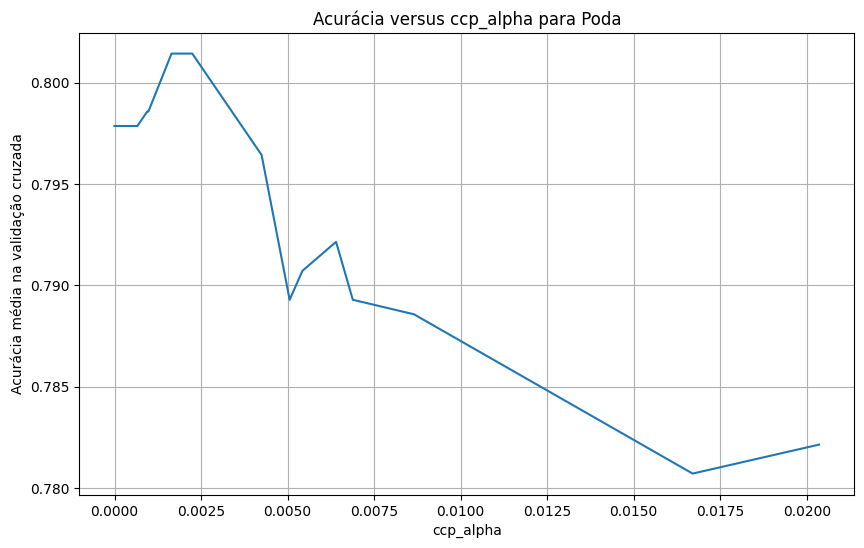


ccp_alpha ótimo encontrado por validação cruzada: 0.0016477516477516538

Modelo podado treinado com optimal ccp_alpha:
DecisionTreeClassifier(ccp_alpha=np.float64(0.0016477516477516538),
                       min_samples_split=100)


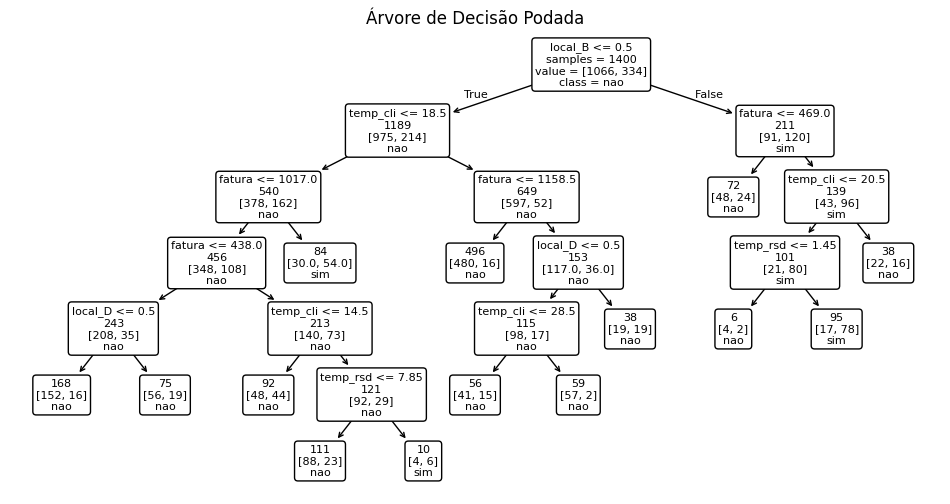

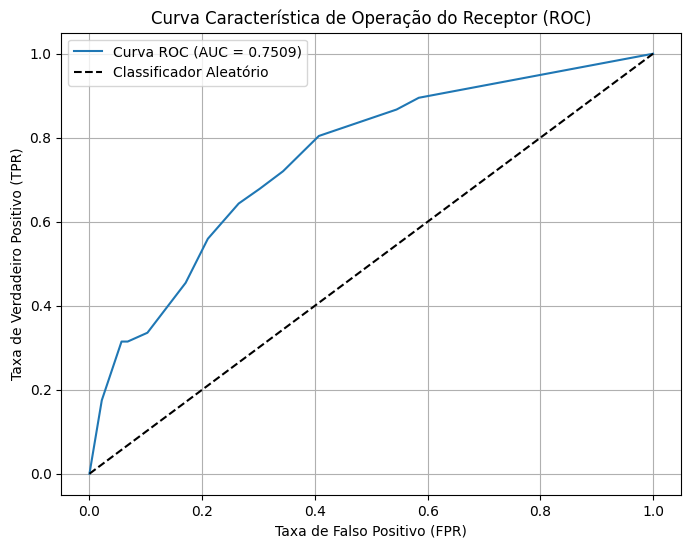

In [2]:
# Importar bibliotecas necessárias.
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Definir a semente geração de números pseudoaleatórios.
np.random.seed(42)

# Carregar e preparar os dados.
# Apagar a primeira coluna (id dos clientes).
df = pd.read_excel("/content/TECAL.xlsx")
df = df.iloc[:, 1:]

# A variável-alvo é cancel (cliente cancela o serviço ou não).
# X_train é o conjunto de variáveis preditoras, na amostra de treino.
# y_train é a variável-alvo, na amostra de treino.
# X_test é o conjunto de variáveis preditoras, na amostra de teste.
# y_train é a variável-alvo, na amostra de teste.
# Dividir a base de dados em amostra de treino (70%) e em amostra de teste (30%).
X = df.drop('cancel', axis=1)
y = df['cancel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Codificação em variáveis dummy para variáveis categóricas.
# Para cada variável categórica, criam-se k-1 variáveis dummy (k é o número de categorias existentes).
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Treinar a árvore de decisão inicial com pre-poda (min_samples_split=100).
model = DecisionTreeClassifier(random_state=42, min_samples_split=100)
model.fit(X_train, y_train)

# Calcular e aplicar a poda (pruning) com validação cruzada.
# Determina todos ccp_alphas e apaga o relativo à arvire trivial.
# Gera gráfico ccp_alpha versus Acurácia Média obtida na validação cruzada.
# Imprime o ccp_alpha ótimo.
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]
cv_results = []
for ccp_alpha in ccp_alphas:
    temp_model = DecisionTreeClassifier(ccp_alpha=ccp_alpha, min_samples_split=100)
    scores = cross_val_score(temp_model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results.append(np.mean(scores))
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, cv_results, linestyle='-')
plt.xlabel("ccp_alpha")
plt.ylabel("Acurácia média na validação cruzada")
plt.title("Acurácia versus ccp_alpha para Poda")
plt.grid(True)
plt.show()
optimal_ccp_alpha = ccp_alphas[np.argmax(cv_results)]
print(f"\nccp_alpha ótimo encontrado por validação cruzada: {optimal_ccp_alpha}")

# Treinar o modelo podado com o ccp_alpha ótimo e imprimir a árvore.
pruned_model = DecisionTreeClassifier(ccp_alpha=optimal_ccp_alpha, min_samples_split=100)
pruned_model.fit(X_train, y_train)
print("\nModelo podado treinado com optimal ccp_alpha:")
print(pruned_model)
plt.figure(figsize=(12, 6))
plot_tree(pruned_model, feature_names=X_train.columns, class_names=pruned_model.classes_,
          impurity=False, filled=False, rounded=True, fontsize=8,  node_ids=False,
          proportion=False, label='root')
plt.title("Árvore de Decisão Podada")
plt.show()

# Determinar probabilidades previstas para a amostra de testes.
test_probs = pruned_model.predict_proba(X_test)
X_test_with_probs = X_test.copy()
X_test_with_probs['probs'] = test_probs[:, 1]

# Apresentar Curva ROC e AUROC.
auc = roc_auc_score(y_test, X_test_with_probs['probs'])
fpr, tpr, thresholds = roc_curve(y_test, X_test_with_probs['probs'], pos_label='sim')
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva Característica de Operação do Receptor (ROC)')
plt.legend()
plt.grid(True)
plt.show()

## **Código 6.3**

Todos os features:  ['Country', 'Region', 'Hemisphere', 'HDI', 'GDP_PerCapita', 'Beer_PerCapita', 'Spirit_PerCapita', 'Wine_PerCapita', 'logwine', 'loggdp']
Features a apagar:  ['Country', 'Region', 'GDP_PerCapita', 'Wine_PerCapita', 'loggdp']
Features restantes: ['Hemisphere', 'HDI', 'Beer_PerCapita', 'Spirit_PerCapita', 'logwine']

--- Resultados do Modelo de Regressão Linear ---
Coeficientes:
HDI                 0.0075
Beer_PerCapita      0.0013
Spirit_PerCapita   -0.0014
logwine            -0.3995
Hemisphere_north    0.1350
Hemisphere_south    0.0606
Intercepto          0.2876
----------------------------------------
MSE do modelo de Regressão Linear: 0.39
----------------------------------------


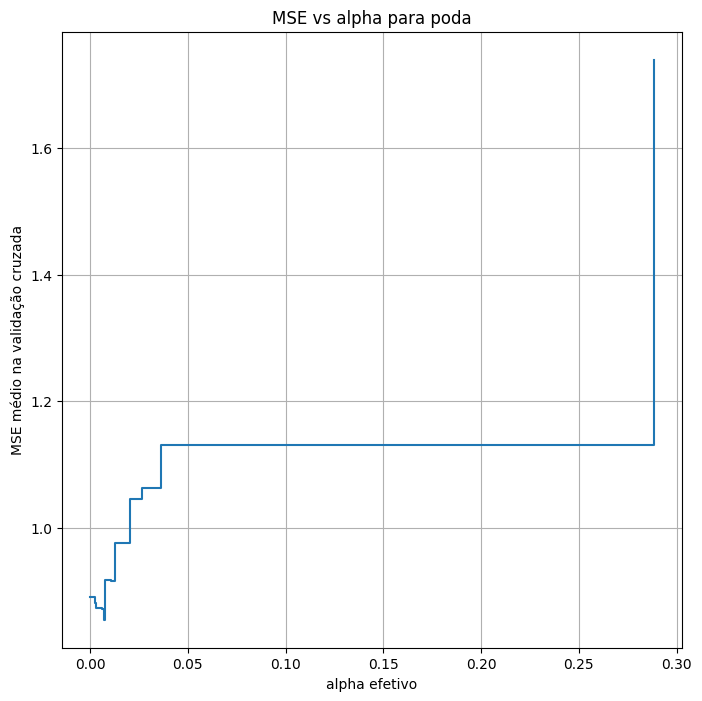


ccp_alpha ótimo encontrado para poda: 0.007036125541125357


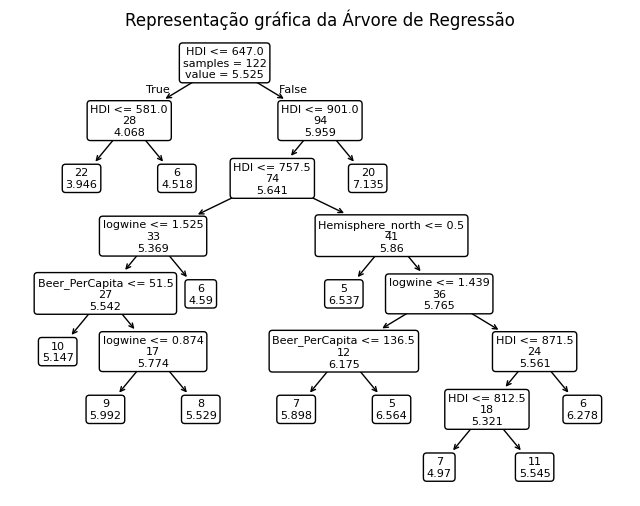


--- Representação textual da Árvore de Regressão ---
|--- HDI <= 647.000
|   |--- HDI <= 581.000
|   |   |--- value: [3.946]
|   |--- HDI >  581.000
|   |   |--- value: [4.518]
|--- HDI >  647.000
|   |--- HDI <= 901.000
|   |   |--- HDI <= 757.500
|   |   |   |--- logwine <= 1.525
|   |   |   |   |--- Beer_PerCapita <= 51.500
|   |   |   |   |   |--- value: [5.147]
|   |   |   |   |--- Beer_PerCapita >  51.500
|   |   |   |   |   |--- logwine <= 0.874
|   |   |   |   |   |   |--- value: [5.992]
|   |   |   |   |   |--- logwine >  0.874
|   |   |   |   |   |   |--- value: [5.529]
|   |   |   |--- logwine >  1.525
|   |   |   |   |--- value: [4.590]
|   |   |--- HDI >  757.500
|   |   |   |--- Hemisphere_north <= 0.500
|   |   |   |   |--- value: [6.537]
|   |   |   |--- Hemisphere_north >  0.500
|   |   |   |   |--- logwine <= 1.439
|   |   |   |   |   |--- Beer_PerCapita <= 136.500
|   |   |   |   |   |   |--- value: [5.898]
|   |   |   |   |   |--- Beer_PerCapita >  136.500
|   |   

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Carregar a planilha HAPPINESSALCOHOLCONSUMPTION.xlsx.
happy = pd.read_excel('/content/HAPPINESSALCOHOLCONSUMPTION.xlsx')

# Substituir 'noth' por 'both' na coluna 'Hemisphere'.
happy['Hemisphere'] = happy['Hemisphere'].replace('noth', 'both')

# Separar a variável dependente (HappinessScore) e as variáveis independentes (features) para ambos os modelos.
X = happy.drop('HappinessScore', axis=1)
y = happy['HappinessScore']

# Apagar alguns features.
print("Todos os features: ", X.columns.tolist())
features_a_apagar = ['Country', 'Region', 'GDP_PerCapita', 'Wine_PerCapita', 'loggdp']
X = X.drop(columns=features_a_apagar, axis=1)
print("Features a apagar: ", features_a_apagar)
print("Features restantes:", X.columns.tolist())

# Converter a coluna 'Hemisphere' para formato numérico usando One-Hot Encoding.
X = pd.get_dummies(X, columns=['Hemisphere'], drop_first=True)


# --- Modelo de Regressão Linear em Python ---

# Inicializar e treinar o modelo de regressão linear
reg_lm = LinearRegression()
reg_lm.fit(X, y)

print("\n--- Resultados do Modelo de Regressão Linear ---")

coeficientes = pd.Series(reg_lm.coef_, index=X.columns)
print("Coeficientes:")
print(coeficientes.round(4).to_string())
print(f"Intercepto          {round(reg_lm.intercept_, 4)}")

# Calcular o MSE (Erro Quadrático Médio)
y_pred_lm = reg_lm.predict(X)
mse_lm = mean_squared_error(y_true=y, y_pred=y_pred_lm)


print("-" * 40)
print(f"MSE do modelo de Regressão Linear: {mse_lm:.2f}")
print("-" * 40)

# --- Modelo de Árvore de Regressão em Python ---

# Inicializar e treinar o modelo de árvore de regressão (sem poda inicial).
reg_arv = DecisionTreeRegressor(random_state=42, min_samples_leaf=5)
reg_arv.fit(X, y)

# Obter os valores de ccp_alpha para cada poda.
path = reg_arv.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas

# Para cada ccp_alpha, treinar uma árvore e avaliar usando validação cruzada.
# Usar validação cruzada de 10 folds.
mse_scores = []
for ccp_alpha in ccp_alphas:
    arvore_regressao_podada = DecisionTreeRegressor(random_state=11, ccp_alpha=ccp_alpha, min_samples_leaf=5)
    # Usamos o negativo do MSE porque cross_val_score maximiza a métrica
    scores = -cross_val_score(arvore_regressao_podada, X, y, scoring="neg_mean_squared_error", cv=5)
    mse_scores.append(np.mean(scores))

# Encontrar o ccp_alpha que minimiza o MSE médio na validação cruzada.
ccp_alpha_otimo = ccp_alphas[np.argmin(mse_scores)]

# Visualizar a relação entre ccp_alpha e MSE.
plt.figure(figsize=(8, 8))
plt.plot(ccp_alphas[:-1], mse_scores[:-1], drawstyle="steps-post")
plt.xlabel("alpha efetivo")
plt.ylabel("MSE médio na validação cruzada")
plt.title("MSE vs alpha para poda")
plt.grid(True)
plt.show()

print(f"\nccp_alpha ótimo encontrado para poda: {ccp_alpha_otimo}")

# Treinar a árvore final com o ccp_alpha otimizado e exibir a árvore.
reg_arvore_podada = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha_otimo, min_samples_leaf=5)
reg_arvore_podada.fit(X, y)
plt.figure(figsize=(8,6))
plot_tree(reg_arvore_podada, feature_names=X.columns.tolist(), filled=False, rounded=True, fontsize=8, impurity=False, node_ids=False, proportion=False, label='root', class_names=None)
plt.title("Representação gráfica da Árvore de Regressão")
plt.show()

# Gerar e imprimir a representação textual da árvore.
print("\n--- Representação textual da Árvore de Regressão ---")
tree_text = export_text(reg_arvore_podada, feature_names=X.columns.tolist(), decimals=3)
print(tree_text)
print("-" * 45)

# Fazer previsões com a árvore podada.
arvore_podada_fit = reg_arvore_podada.predict(X)

# Calcular o MSE da árvore podada.
mse_arvore_podada = mean_squared_error(y_true=y, y_pred=arvore_podada_fit)

print(f"MSE do modelo de Árvore de Regressão: {mse_arvore_podada:.2f}")
print("-" * 45)